In [24]:
import numpy as np
import matplotlib.pyplot as plt

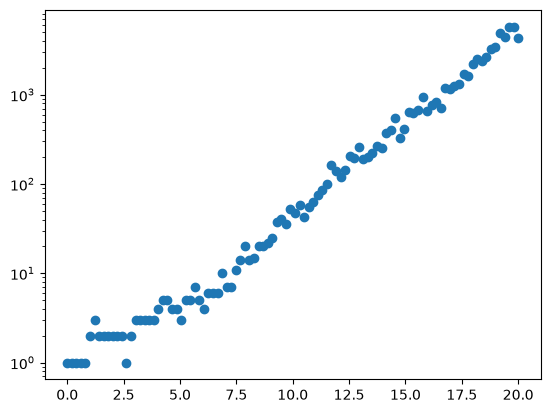

In [25]:
def colonia_sim(N0 = 1, tau = 1, T0=0, T1=1, steps = 10000, measurements=None, m=10, sigma_log=0.05, seed=42):
    np.random.seed(seed)


    times = np.linspace(T0,T1,steps)
    sizes = np.zeros(steps)
    sizes[0] = N0
    N = N0

    p = tau*(T1-T0)/steps
    for i in range(1,steps):
        N = N + np.random.binomial(N,p)
        sizes[i] = N


    if measurements is None:
        measurements = np.linspace(T0, T1, m)
    else:
        measurements = np.sort(np.array(measurements))

    measured_sizes = np.interp(measurements, times, sizes)
    measured_sizes = np.round(measured_sizes).astype(int)


    noise = np.random.lognormal(0, sigma_log, size=len(measurements))
    measured_sizes = np.maximum(1, np.round(measured_sizes * noise)).astype(int)


    return measurements, measured_sizes

times, sizes = colonia_sim(tau=0.5,N0=1,T1=20,m=100,sigma_log=0.2)

plt.scatter(times,sizes)
plt.yscale("log")

Parámetros optimizados: N0 = 0.2757, gamma = 0.4982


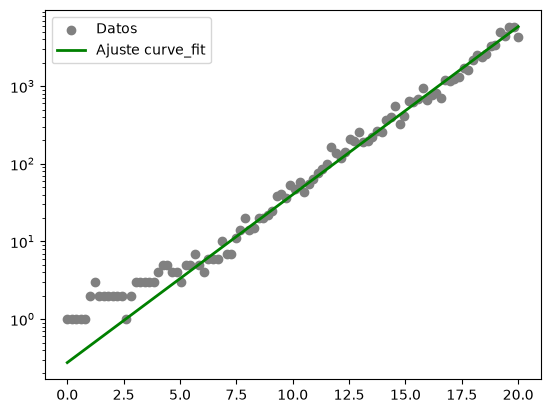

In [26]:
from scipy.optimize import curve_fit

def modelo_exponencial(t, N0, gamma):
    return N0*np.exp(gamma*t)


popt, pcov = curve_fit(modelo_exponencial, times, sizes)

print(f"Parámetros optimizados: N0 = {popt[0]:.4f}, gamma = {popt[1]:.4f}")

# 4. Graficar
plt.scatter(times, sizes, label='Datos', color='gray')
plt.plot(times, modelo_exponencial(times, *popt), label='Ajuste curve_fit', color='green', linewidth=2)
plt.yscale('log')
plt.legend()
plt.show()


In [49]:
import pymc as pm
import arviz as az


#generamos los datos. Requerimos tener los valores verdaderos
w0_true = 0.5
w1_true = 0.5
sigma_true = 0.2
N = 10

def modelo_recta(x,w0,w1):
    return w0 + x*w1

def ruido(x,sigma):
    return np.random.normal(0,sigma,size=len(x))

x_data = np.linspace(0,100,N)
y_data = modelo_recta(x_data,w0_true,w1_true) + ruido(x_data,sigma_true)


In [ ]:

with pm.Model() as modelo_regresion:
    w0 = pm.Uniform("w0",lower=0,upper=1)
    w1 = pm.Uniform("w1",lower=0,upper=1)
    sigma = pm.Uniform("sigma",0,1)

    mu = modelo_recta(x_data,w0,w1)
    
    y_obs = pm.Normal("y_obs",mu=mu,sigma=sigma,observed=y_data)

    idata = pm.sample(draws=100,tune=100)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w0, w1, sigma]


Output()

Sampling 4 chains for 100 tune and 100 draw iterations (400 + 400 draws total) took 18 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [55]:
modelo_regresion

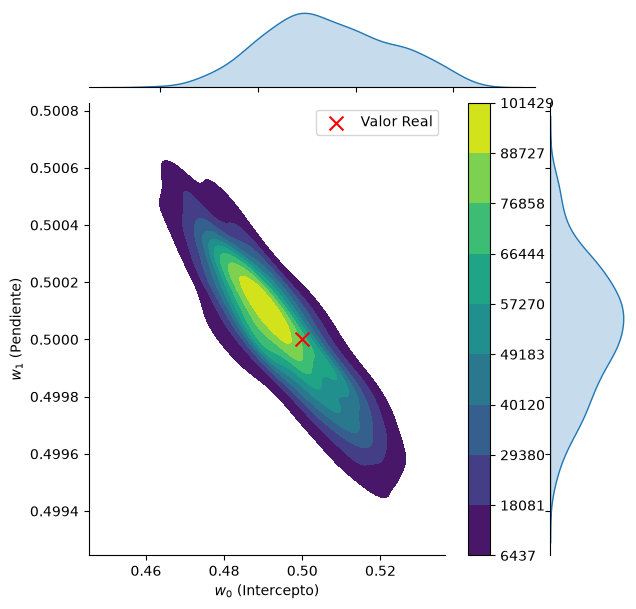

In [47]:
import seaborn as sns
# Extraer y aplanar las muestras de idata (asumiendo que corriste pm.sample())
w0_samples = idata.posterior["w0"].values.flatten()
w1_samples = idata.posterior["w1"].values.flatten()

# Crear un gráfico conjunto con densidad 2D (KDE)
# 'kind="kde"' lo convierte en un mapa de calor suavizado con contornos.
jg = sns.jointplot(x=w0_samples, y=w1_samples, kind="kde", cmap="viridis", fill=True, cbar=True)

# Añadir etiquetas a los ejes
jg.set_axis_labels(xlabel=r"$w_0$ (Intercepto)", ylabel=r"$w_1$ (Pendiente)")

# (Opcional) Marcar los valores reales con un punto rojo para comparar
jg.ax_joint.scatter(w0_true, w1_true, color="red", marker="x", s=100, label="Valor Real")
jg.ax_joint.legend()

plt.show()



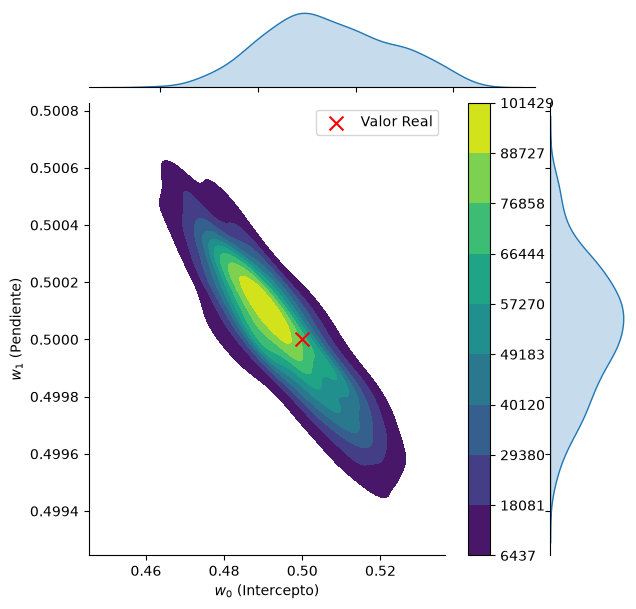

In [ ]:
import seaborn as sns
# Extraer y aplanar las muestras de idata (asumiendo que corriste pm.sample())
w0_samples = idata.posterior["w0"].values.flatten()
w1_samples = idata.posterior["w1"].values.flatten()

# Crear un gráfico conjunto con densidad 2D (KDE)
# 'kind="kde"' lo convierte en un mapa de calor suavizado con contornos.
jg = sns.jointplot(x=w0_samples, y=w1_samples, kind="kde", cmap="viridis", fill=True, cbar=True)

# Añadir etiquetas a los ejes
jg.set_axis_labels(xlabel=r"$w_0$ (Intercepto)", ylabel=r"$w_1$ (Pendiente)")

# (Opcional) Marcar los valores reales con un punto rojo para comparar
jg.ax_joint.scatter(w0_true, w1_true, color="red", marker="x", s=100, label="Valor Real")
jg.ax_joint.legend()

plt.show()



In [1]:
import arviz as az

# Comprobamos si el atributo realmente existe ahora
print(az.__file__)
print(dir(az))  # Debería mostrar una lista gigante donde figure 'plot_posterior'
print(hasattr(az, "plot_posterior"))  # Debería devolver True

e:\Austral\inferencia-bayesiana\venv\Lib\site-packages\arviz\__init__.py
['AzStatsDaAccessor', 'AzStatsDsAccessor', 'AzStatsDtAccessor', 'ELPDData', 'MCMCAdapter', 'MigrationWarning', 'NumPyroInferenceAdapter', 'PlotCollection', 'PlotMatrix', 'SVIAdapter', 'SamplingWrapper', '_MIGRATION_GUIDE_URL', '__builtins__', '__cached__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_log', 'accessors', 'add_bands', 'add_lines', 'base', 'bayes_factor', 'bayesian_r2', 'bfmi', 'ci_in_rope', 'citations', 'clear_data_home', 'combine_plots', 'compare', 'convert_to_dataset', 'convert_to_datatree', 'dataset_to_dataarray', 'dataset_to_dataframe', 'diagnose', 'dict_to_dataset', 'ecdf', 'ess', 'eti', 'explode_dataset_dims', 'extract', 'from_cmdstanpy', 'from_dict', 'from_emcee', 'from_netcdf', 'from_numpyro', 'from_numpyro_svi', 'from_zarr', 'generate_dims_coords', 'generate_survival_curves', 'get_data_home', 'get_function', 'get_log_